# Лабораторная работа №2 Степанов Дмитрий

##  Оценка основного тона на основе АКФ

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from statsmodels.tsa.stattools import acf

In [10]:
# Чтение WAV файла
fs, x = wavfile.read('input.wav')  # Замените на имя вашего файла

#print(f"Тип данных: {x.dtype}")

# Если сигнал стерео (два канала), выберем один (например, левый канал)
if len(x.shape) > 1:
    x = x[:, 0]


# # Ищем ненулевые отсчеты чтобы выбрать корректный промежуток для анализирования
# print(np.where(x!=0))
# #print(x[20000:20500])

x_min = 20000
x_max = 30000

N = x_max-x_min
mean = np.mean(x[x_min:x_max])

# Функция для вычисления АКФ
def my_acf(x, m):
    """Вычисление автокорреляционной функции для сигнала x на сдвиге m"""
    sum = 0.0
    for k in range(0, N-m):
        sum = sum + (x[k]-mean)*(x[k+m]-mean)
    
    return sum/(N-m)
        

# Проверка АКФ для нескольких значений m
acf_values = [my_acf(x[x_min:x_max], m) for m in range(0, N)]
# Для проверки работы с библиотечной функцией
acf_biblioteka = acf(x[x_min:x_max], adjusted=True, nlags= N+1)

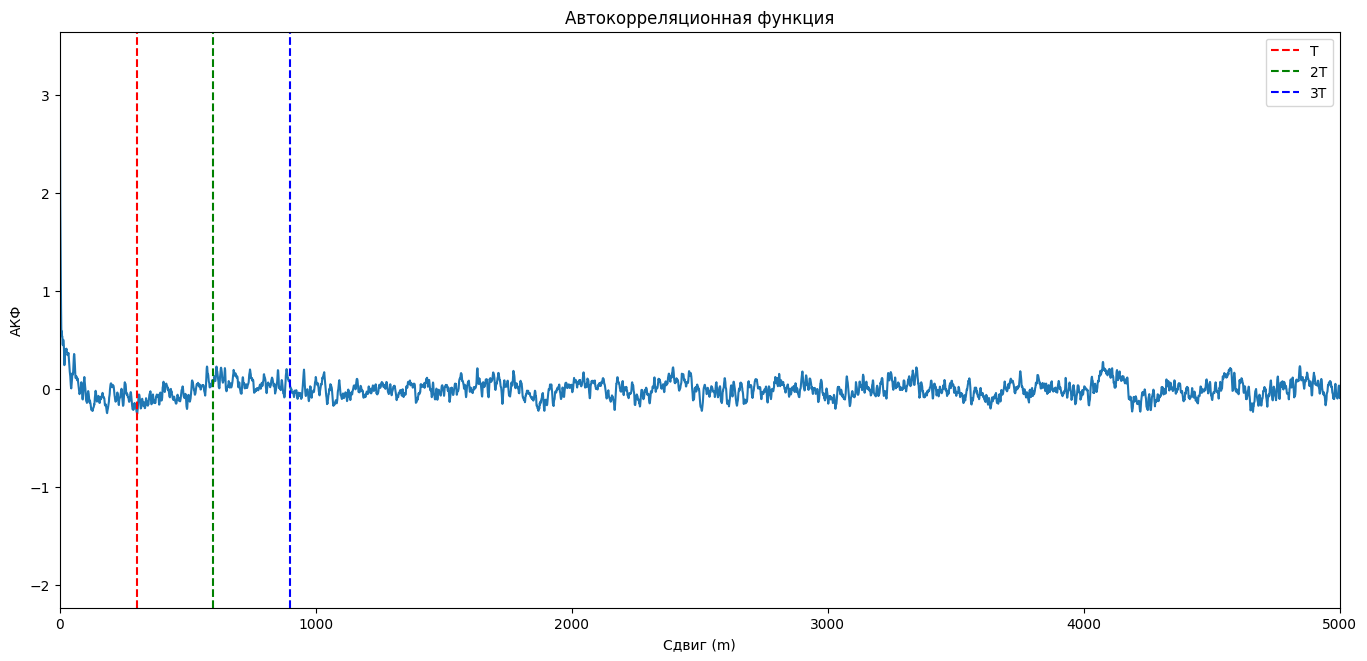

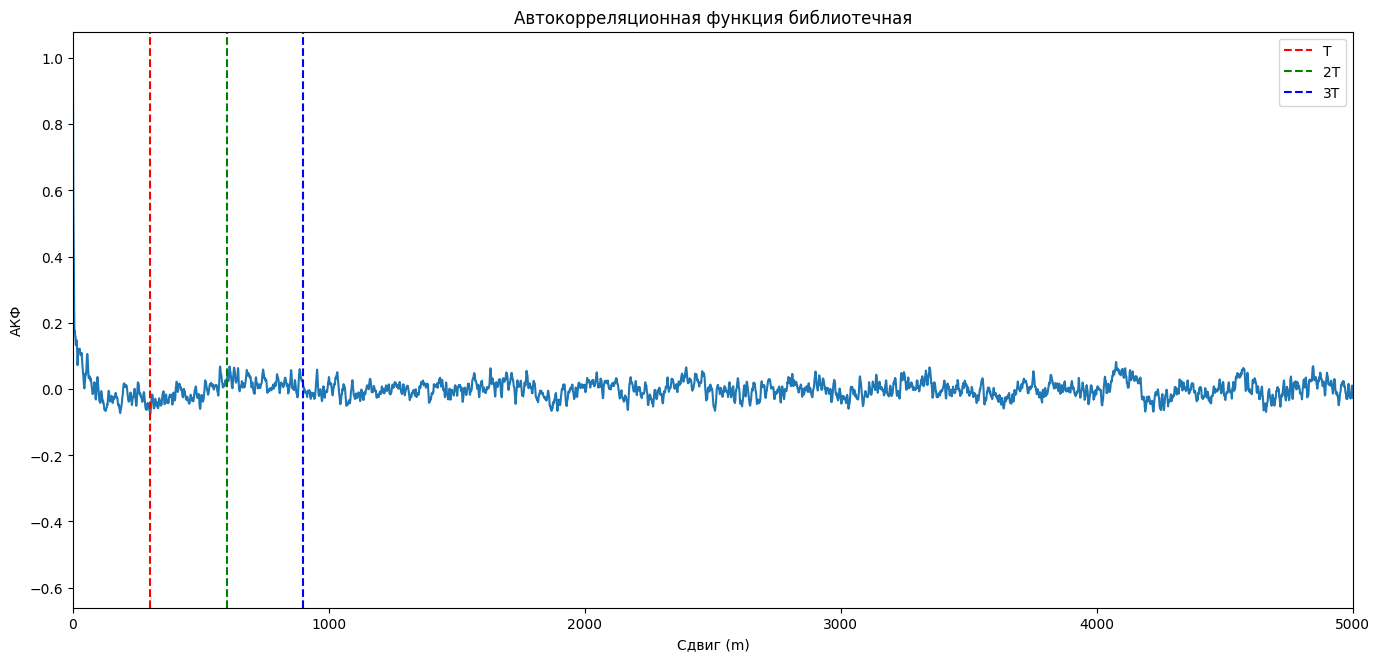

Период пиков на АКФ = 300 отсчетам
Тогда период = 300/48000 кГц = 0.00625 сек
Средняя частота основного тона = 1/0.00625 сек = 160.0 Гц


In [11]:
# Построение графика АКФ
plt.plot(range(0, N), acf_values)
plt.xlabel('Сдвиг (m)')
plt.ylabel('АКФ')
plt.title('Автокорреляционная функция')
plt.axvline(x=300, color='r', linestyle='--', label='T')
plt.axvline(x=600, color='g', linestyle='--', label='2T')
plt.axvline(x=900, color='b', linestyle='--', label='3T')
plt.xlim(0, N/2)
plt.subplots_adjust(left=0, right=2, top = 1.2, bottom = 0)
plt.legend()
plt.show()


# Построение графика для проверки работы с библиотечной функцией
plt.plot(range(0, N), acf_biblioteka[:N])
plt.xlabel('Сдвиг (m)')
plt.ylabel('АКФ')
plt.title('Автокорреляционная функция библиотечная')
plt.axvline(x=300, color='r', linestyle='--', label='T')
plt.axvline(x=600, color='g', linestyle='--', label='2T')
plt.axvline(x=900, color='b', linestyle='--', label='3T')
plt.xlim(0, N/2)
plt.subplots_adjust(left=0, right=2, top = 1.2, bottom = 0)
plt.legend()
plt.show()

# Вывод среднего значения для частоты основного тона
print("Период пиков на АКФ = 300 отсчетам")
print(f"Тогда период = 300/{fs} кГц = {300/fs} сек")
print(f"Средняя частота основного тона = 1/{300/fs} сек = {1/(300/fs)} Гц")

## Оценка основного тона на основе ДВПФ

C:\Users\matye\AppData\Local\Temp\ipykernel_13252\2676566625.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  E[i] = np.exp(-2j * np.pi * f * n / fs)  # e^(-j*(2*pi*f/fs)*n)


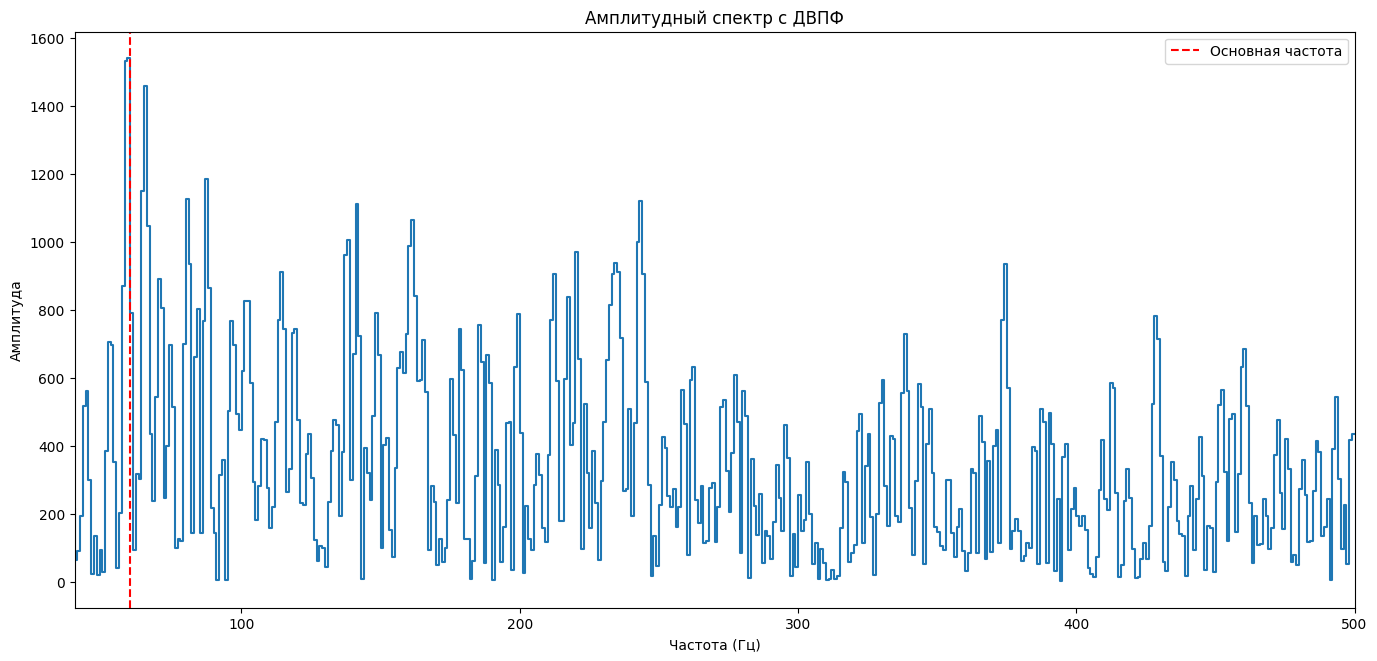

Основная частота тона: 60.00600060006 Гц


In [12]:
def my_dtft(x, fs, freqs):
    X = np.zeros(N, dtype=complex)  # Массив для хранения результатов
    E = np.zeros((len(freqs), N)) 

    # Подготовим вектор для комплексных экспонент
    n = np.arange(N)  # Вектор отсчетов сигнала

    # Для каждой частоты, вычисляем спектр
    for i, f in enumerate(freqs):
        # Комплексная экспонента для частоты f                w
        E[i] = np.exp(-2j * np.pi * f * n / fs)  # e^(-j*(2*pi*f/fs)*n)
        
    # Скалярное произведение: сигнал x на экспоненту
    X = np.dot(E, x[x_min:x_max])

    # Амплитудный спектр (модуль комплексных чисел)
    amplitude = np.abs(X)

    return amplitude


freqs = np.linspace(0, N, N)
amplitude = my_dtft(x, fs, freqs)
fundamental_frequency = freqs[np.argmax(amplitude)]

# Визуализация амплитудного спектра
plt.step(freqs[:len(freqs)//2], amplitude[:len(amplitude)//2])  # Отображаем только положительные частоты
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.title('Амплитудный спектр с ДВПФ')
plt.axvline(x=fundamental_frequency, color='r', linestyle='--', label='Основная частота')
plt.xlim(40, 500)
plt.subplots_adjust(left=0, right=2, top = 1.2, bottom = 0)
plt.legend()
plt.show()

# Вывод основной частоты
print(f"Основная частота тона: {fundamental_frequency} Гц")

## Оценка основного тона с помощью Google REAPER

выполнено на исследуемом участке

In [13]:
import pyreaper

Average fundamental frequency: nan


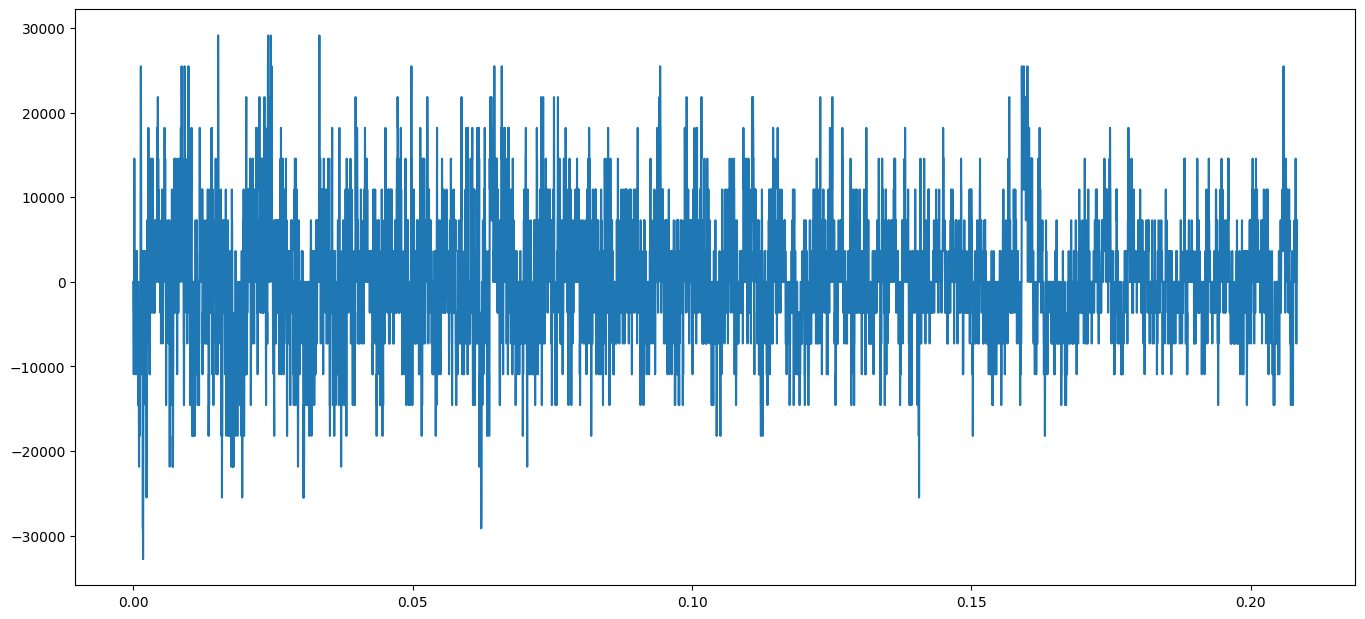

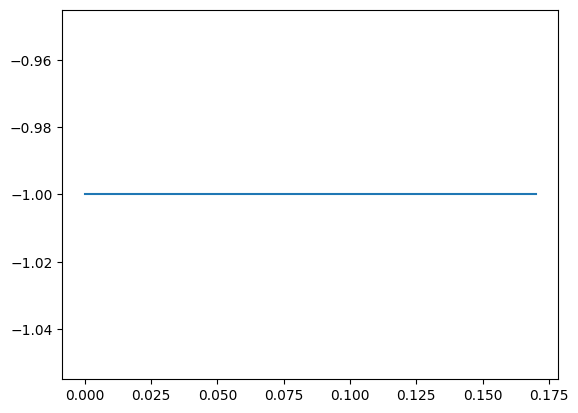

In [14]:
x_use = x[x_min:x_max]
# Нормировка входного сигнала
x_use = x_use.astype(np.float32) / max(abs(min(x_use)), abs(max(x_use)))
t = np.linspace(0, (len(x_use) - 1) / fs, len(x_use))

# Подготовка данных для reaper
int16_info = np.iinfo(np.int16)
x_use = x_use * min(int16_info.min, int16_info.max)
x_use = x_use.astype(np.int16)

# Вызов reaper
pm_times, pm, f_times, f, _ = pyreaper.reaper(x_use, fs)

# Отображение позиций пиков
plt.figure('[Reaper] Pitch Marks')
plt.plot(t, x_use)
plt.scatter(pm_times[pm == 1], x_use[(pm_times * fs).astype(int)][pm == 1], marker='x', color='red')
plt.subplots_adjust(left=0, right=2, top = 1.2, bottom = 0)

# Отображение значений основной частоты
plt.figure('[Reaper] Fundamental Frequency')
plt.plot(f_times, f)
print('Average fundamental frequency:', np.mean(f[f != -1]))
plt.show()

## Изменение основного тона на основе алгоритма PSOLA

In [29]:
from scipy.signal import triang

ImportError: cannot import name 'triang' from 'scipy.signal' (c:\Users\matye\Python\DSP-Lab4\DSP-Experiments\venv\Lib\site-packages\scipy\signal\__init__.py)

In [ ]:
window = triang(3)
print(len(window))

3


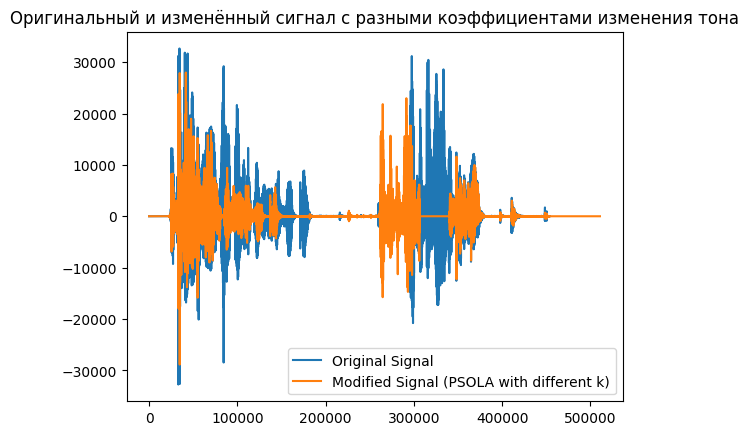

In [ ]:
x_use = x
# Нормировка входного сигнала
x_use = x_use.astype(np.float32) / max(abs(min(x_use)), abs(max(x_use)))
t = np.linspace(0, (len(x_use) - 1) / fs, len(x_use))

# Подготовка данных для reaper
int16_info = np.iinfo(np.int16)
x_use = x_use * min(int16_info.min, int16_info.max)
x_use = x_use.astype(np.int16)

# Вызов reaper
_, _, f_times, f, _ = pyreaper.reaper(x_use, fs)
f=np.where(f>0)

# Разделение сигнала на 4 части
num_parts = 4
part_length = len(x_use) // num_parts
signal_parts = [x_use[i * part_length:(i + 1) * part_length] for i in range(num_parts)]

# Разные коэффициенты изменения тона для каждой части
k_values = [0.7, 1.0, 1.3, 1.5]  # Разные коэффициенты для каждой части

# Алгоритм PSOLA
def psola(x, fs, f, k):
    lN = len(x)
    output = np.zeros(int(lN * k))  # Новый сигнал с изменённым тоном
    segment_length = int(fs / np.min(f))  # Длина сегмента, соответствующая минимальной частоте

    for i in range(0, len(x) - segment_length, segment_length):
        segment = x[i:i + segment_length]
        if len(segment) < segment_length:
            break

        # Изменение длины сегмента
        new_segment_length = int(len(segment) * k)
        segment_resized = np.interp(np.linspace(0, len(segment), new_segment_length), np.arange(len(segment)), segment)
        
        # Оконная функция для сглаживания переходов
        window = triang(len(segment_resized))

        # Окно и наложение
        segment_resized_windowed = segment_resized * window
        
        
        # Убедимся, что длина не выходит за границы массива output
        end_index = i + len(segment_resized_windowed)
        if end_index <= len(output):
            output[i:i + len(segment_resized_windowed)] += segment_resized_windowed
        else:
            if len(output[i:] == 0): break
            output[i:] += segment_resized_windowed[:len(output) - i]

    return output

# Применяем PSOLA для каждой части сигнала с разными коэффициентами
modified_signal = np.concatenate([psola(part, fs, f, k) for part, k in zip(signal_parts, k_values)])

# Сохраняем результат в новый WAV файл
wavfile.write('output_modified_four_parts.wav', fs, np.int16(modified_signal / np.max(np.abs(modified_signal)) * 32767))  # Нормализуем перед сохранением

# Визуализируем результат
plt.figure()
plt.plot(x_use, label="Original Signal")
plt.plot(modified_signal, label="Modified Signal (PSOLA with different k)")
plt.legend()
plt.title("Оригинальный и изменённый сигнал с разными коэффициентами изменения тона")
plt.show()